In [1]:
import data

df, acc_times = data.get_data(year := 2021)

data.style_table(df)

,name,score,stars,1.1,1.2,2.1,2.2,3.1,3.2,4.1,4.2,5.1,5.2,6.1,6.2,accumulated_time
1,Arnau Q,172,12,08:56:48,02:38,08:17:02,03:07,09:44:49,30:14,10:07:12,11:57,09:28:56,20:05,10:00:58,01:09,01:09:10
2,Andreu Vall Hernàndez,153,12,08:24:30,07:44,09:11:17,02:02,12:33:15,27:39,10:01:43,09:16,11:17:50,08:50,11:45:06,00:49,56:20
3,David Rial Figols,150,12,10:36:31,08:55,09:31:31,02:43,07:09:12,36:45,16:58:57,06:52,11:25:20,23:36,09:46:03,01:03,01:19:54
4,enriquejiwa,127,12,12:32:01,39:37,10:01:28,10:00,10:19:35,43:50,11:00:48,15:45,11:49:26,09:26,11:19:36,09:17,02:07:55
5,Arnau Martínez Tomàs,121,12,23:53:14,45:12,10:23:49,25:47,12:59:36,30:52,11:25:20,12:41,12:45:06,23:25,10:57:01,25:47,02:43:44
6,Antonio Tigri,117,12,15:22:36,12:46,10:56:21,03:52,11:37:32,34:25,12:27:54,17:41,13:36:21,23:21,10:39:33,02:52:50,04:24:55
7,EstherRH00,105,12,13:11:40,42:39,21:05:03,03:25,13:39:55,23:11,13:20:28,16:00,13:01:04,20:08,13:01:53,12:41,01:58:04
8,albertsalles4,130,10,10:22:07,08:49,09:21:50,02:31,10:10:11,15:24,11:54:16,12:10,10:26:11,09:42,NaT,NaT,NaT
9,sarabase,83,10,18:32:58,18:29,12:06:40,03:32,11:23:58,55:36,17:37:14,06:45,16:44:35,06:17,NaT,NaT,NaT


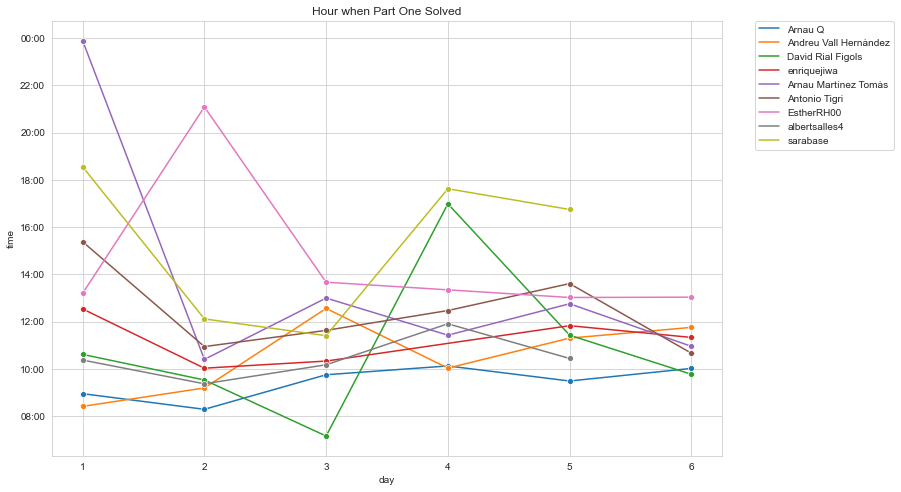

In [9]:
import matplotlib.pyplot as plt
from datetime import datetime
import matplotlib.dates as md
import seaborn as sns
import pandas as pd

days = int(df.columns[-2].split('.')[0])

n_days = int(df.columns[-2].split('.')[0])
too_far = datetime.strptime(f'2/12/{year} 06', '%d/%m/%Y %H')

times_data = []
for _, row in df.iterrows():
    for day in range(1, n_days+1):
        date = row[f'{day}.1']
        if not pd.isnull(date):
            time = date-pd.Timedelta(day-1, unit='d')
            if time < too_far:
                times_data.append({'name': row['name'], 'day': day, 'time': time})

times = pd.DataFrame(times_data)

plt.figure(figsize=(12,8))

sns.set_style("whitegrid")

ax = sns.lineplot(data=times, x='day', y='time', hue='name', marker='o')

ax.set_title('Hour when Part One Solved')

ax.set_xticks(range(1, days+1))
ax.yaxis.set_major_formatter(md.DateFormatter('%H:%M'))

plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)

plt.savefig('static_plots/part1.png', bbox_inches='tight')

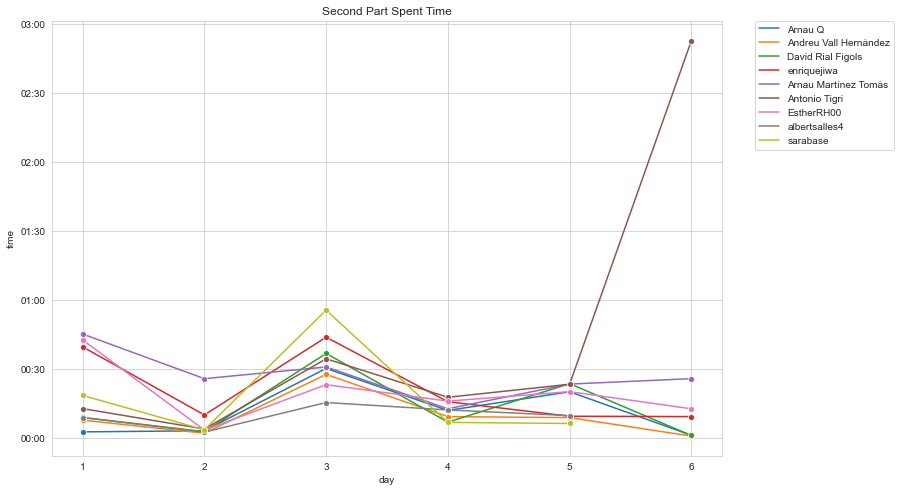

In [10]:
base = datetime.strptime('1/12/21', '%d/%m/%y')

times_data = []
for _, row in df.iterrows():
    for day in range(1, n_days+1):
        time = row[f'{day}.2']
        if not pd.isnull(time):
            times_data.append({'name': row['name'], 'day': day, 'time': time+base})

times = pd.DataFrame(times_data)

plt.figure(figsize=(12,8))

ax = sns.lineplot(data=times, x='day', y='time', hue='name', marker='o')

ax.set_xticks(range(1, days+1))
ax.yaxis.set_major_formatter(md.DateFormatter('%H:%M'))
ax.set_title('Second Part Spent Time')

plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)

plt.savefig('static_plots/part2.png', bbox_inches='tight')

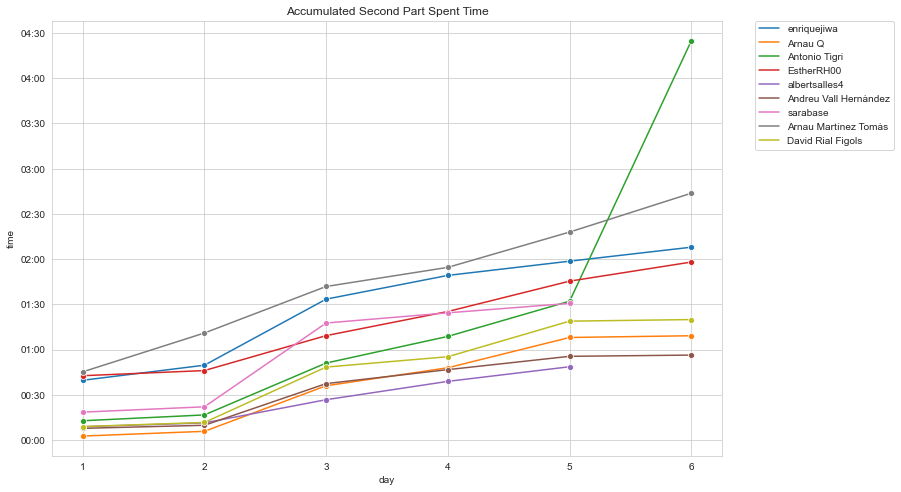

In [11]:
times_data = []
for _, row in acc_times.iterrows():
    for day in range(1, n_days+1):
        time = row[str(day)]
        if not pd.isnull(time):
            times_data.append({'name': row['name'], 'day': day, 'time': time+base})

times = pd.DataFrame(times_data)

plt.figure(figsize=(12,8))

ax = sns.lineplot(data=times, x='day', y='time', hue='name', marker='o')

ax.set_xticks(range(1, days+1))
ax.yaxis.set_major_formatter(md.DateFormatter('%H:%M'))
ax.set_title('Accumulated Second Part Spent Time')

plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)

plt.savefig('static_plots/part2_total.png', bbox_inches='tight')